### 3 EXPERIMENTOS DE MINERIA DE DATOS PARA PREDICCION DE DEFECTOS DE SOFTWARE

- Julio César Gutiérrez Orozco
- María José Miranda López
- Siloé Cristina Campos Víquez



##### Implementamos los experimentos descritos en la seccion de "Experimental Design" del paper. 
- Se utilizan los siguientes datasets (CM1, JM1, KC1) para la evaluación de algoritmos de clasificación y redes neuronales en la predicción de modulos defectuosos.

##### 1) Importamos las librerias necesarias:

- Configuramos el estilo y tamaño de los graficos
- Agregamos la semilla de reproductividad

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo para graficos profesionales
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
sns.set_palette("Set2")

# Semilla para reproducibilidad
RANDOM_STATE = 42

# Configurar tamaño de figuras
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

##### 2) Ruta de datasets:

In [62]:
DATASETS = {
    'CM1': '..\data\cm1.csv',
    'JM1': '..\data\jm1.csv',
    'KC1': '..\data\kc1.csv'
}

print("Datasets definidos:")
for nombre, ruta in DATASETS.items():
    print(f"  {nombre}: {ruta}")

Datasets definidos:
  CM1: ..\data\cm1.csv
  JM1: ..\data\jm1.csv
  KC1: ..\data\kc1.csv


#### 3) Cargamos los dataset

- Identificamos la variable objetivo
- Eliminamos columnas no numéricas
- Manejamos los valores nuelos si existen

- X = DataFrame con atributos (solo numericos)
- Y = Series con la variable objetivo donde 0 es no defectuoso, 1 es defectuoso

In [63]:
def cargar_dataset(ruta, nombre):
    df = pd.read_csv(ruta)
    
    # Identificar columna objetivo
    posibles_target = ['defects', 'Defects', 'defective', 'Defective', 'bug']
    target_col = None
    for col in posibles_target:
        if col in df.columns:
            target_col = col
            break
    
    if target_col is None:
        print(f"Error: No se encontro columna objetivo en {nombre}")
        print(f"Columnas disponibles: {df.columns.tolist()}")
        return None, None, None
    
    # Convertir target a binario (0/1)
    if df[target_col].dtype == 'object':
        df[target_col] = df[target_col].map({'Y': 1, 'N': 0, 'True': 1, 'False': 0, 'true': 1, 'false': 0})
    
    y = df[target_col].astype(int)
    X = df.drop(columns=[target_col])
    
    # Seleccionar solo columnas numericas
    columnas_numericas = X.select_dtypes(include=[np.number]).columns
    X = X[columnas_numericas]
    
    # Contar valores nulos
    nulos_por_columna = X.isnull().sum()
    total_nulos = nulos_por_columna.sum()
    
    # Rellenar nulos con la media
    if total_nulos > 0:
        X = X.fillna(X.mean())
    
    info = {
        'nombre': nombre,
        'instancias': X.shape[0],
        'atributos': X.shape[1],
        'defectos': y.sum(),
        'pct_defectos': (y.sum() / len(y)) * 100,
        'nulos': total_nulos,
        'columnas_nulas': nulos_por_columna[nulos_por_columna > 0].to_dict()
    }
    
    return X, y, info

#### 4) Funciones para realizar el EDA
Realizamos un analisis exploratorio completo para cada dataset generando:
- Distribucion de la variable objetivo
- Histogramas de atributos
- Matriz de correlacion
- Boxplots para detectar outliers

In [64]:
def realizar_eda(X, y, info):
    nombre = info['nombre']
    print(f"\n{'='*60}")
    print(f"EDA PARA DATASET: {nombre}")
    print(f"{'='*60}")
    print(f"Instancias: {info['instancias']}")
    print(f"Atributos: {info['atributos']}")
    print(f"Defectos: {info['defectos']} ({info['pct_defectos']:.1f}%)")
    if info['nulos'] > 0:
        print(f"Valores nulos encontrados: {info['nulos']}")
        print(f"Columnas con nulos: {list(info['columnas_nulas'].keys())}")
    
    # 4.1 Distribucion de la variable objetivo
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Analisis Exploratorio - {nombre}', fontsize=14, fontweight='bold')
    
    # Grafico de barras: defectuoso vs no defectuoso
    defect_counts = y.value_counts()
    axes[0, 0].bar(['No Defectuoso (0)', 'Defectuoso (1)'], defect_counts.values, 
                   color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[0, 0].set_title(f'Distribucion de Clases\n(Defectos: {info["pct_defectos"]:.1f}%)')
    axes[0, 0].set_ylabel('Numero de Modulos')
    for i, v in enumerate(defect_counts.values):
        axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')
    
    # 4.2 Histograma de los primeros 9 atributos (o menos)
    n_atributos_mostrar = min(9, X.shape[1])
    atributos_para_hist = X.columns[:n_atributos_mostrar]
    
    for i, col in enumerate(atributos_para_hist):
        ax_idx = i + 1
        if ax_idx >= 4:
            break
        ax = axes[ax_idx // 2, ax_idx % 2] if ax_idx < 4 else None
        if ax is not None:
            ax.hist(X[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
            ax.set_title(f'Histograma: {col}')
            ax.set_xlabel('Valor')
            ax.set_ylabel('Frecuencia')
    
    for idx in range(len(atributos_para_hist), 3):
        ax = axes[idx // 2, idx % 2] if idx < 4 else None
        if ax is not None:
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'../eda_{nombre}_histogramas.png', dpi=150)
    plt.show()
    
    # 4.3 Matriz de correlacion
    plt.figure(figsize=(14, 12))
    
    atributos_corr = X.columns[:min(20, X.shape[1])]
    corr_matrix = X[atributos_corr].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title(f'Matriz de Correlacion - {nombre}\n(primeros {len(atributos_corr)} atributos)', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../eda_{nombre}_correlacion.png', dpi=150)
    plt.show()
    
    # 4.4 Boxplots para detectar outliers (primeros 12 atributos)
    n_boxplots = min(12, X.shape[1])
    atributos_box = X.columns[:n_boxplots]
    n_rows = (n_boxplots + 3) // 4
    
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
    fig.suptitle(f'Boxplots de Atributos - {nombre}\n(Valores normalizados para visualizacion)', fontsize=12)
    
    X_scaled = StandardScaler().fit_transform(X[atributos_box])
    X_scaled_df = pd.DataFrame(X_scaled, columns=atributos_box)
    
    for i, col in enumerate(atributos_box):
        row, col_idx = i // 4, i % 4
        if n_rows == 1:
            ax = axes[col_idx]
        else:
            ax = axes[row, col_idx]
        
        ax.boxplot(X_scaled_df[col].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#3498db', color='black'),
                   whiskerprops=dict(color='black'),
                   capprops=dict(color='black'),
                   medianprops=dict(color='red', linewidth=2))
        ax.set_title(col)
        ax.set_ylabel('Valor (normalizado)')
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    
    for j in range(i + 1, n_rows * 4):
        row, col_idx = j // 4, j % 4
        if n_rows == 1:
            axes[col_idx].axis('off')
        else:
            axes[row, col_idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'../eda_{nombre}_boxplots.png', dpi=150)
    plt.show()
    
    # 4.5 Resumen estadistico
    print(f"\nResumen estadistico de {nombre}:")
    print(X.describe().round(2))

#### 5) Ejecutamos el EDA para los 3 datasets

INICIANDO ANALISIS EXPLORATORIO DE DATOS (EDA)

EDA PARA DATASET: CM1
Instancias: 498
Atributos: 21
Defectos: 49 (9.8%)


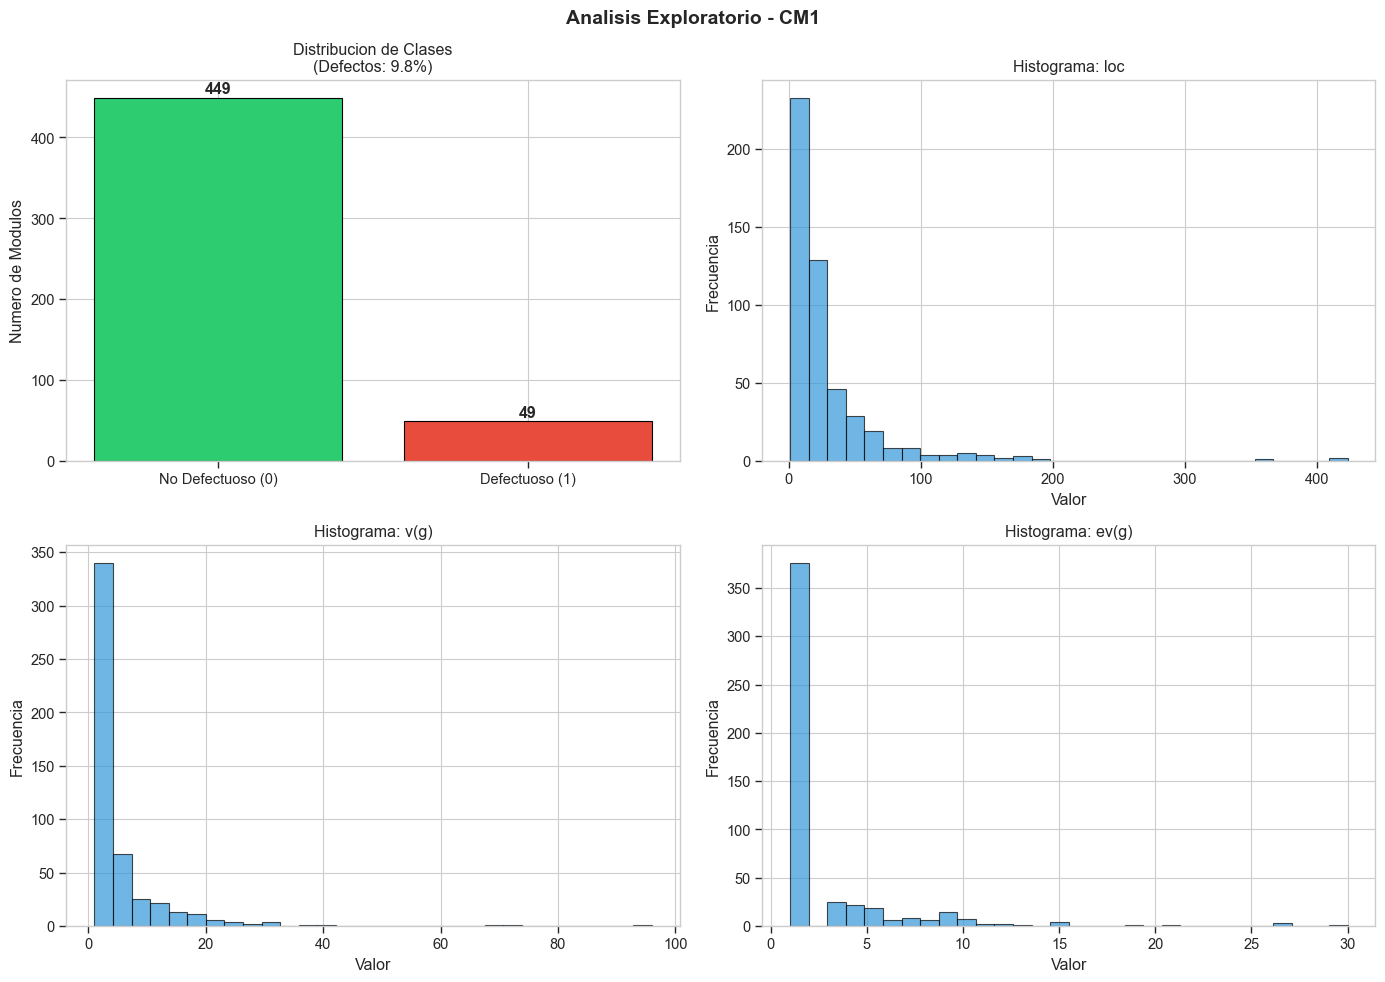

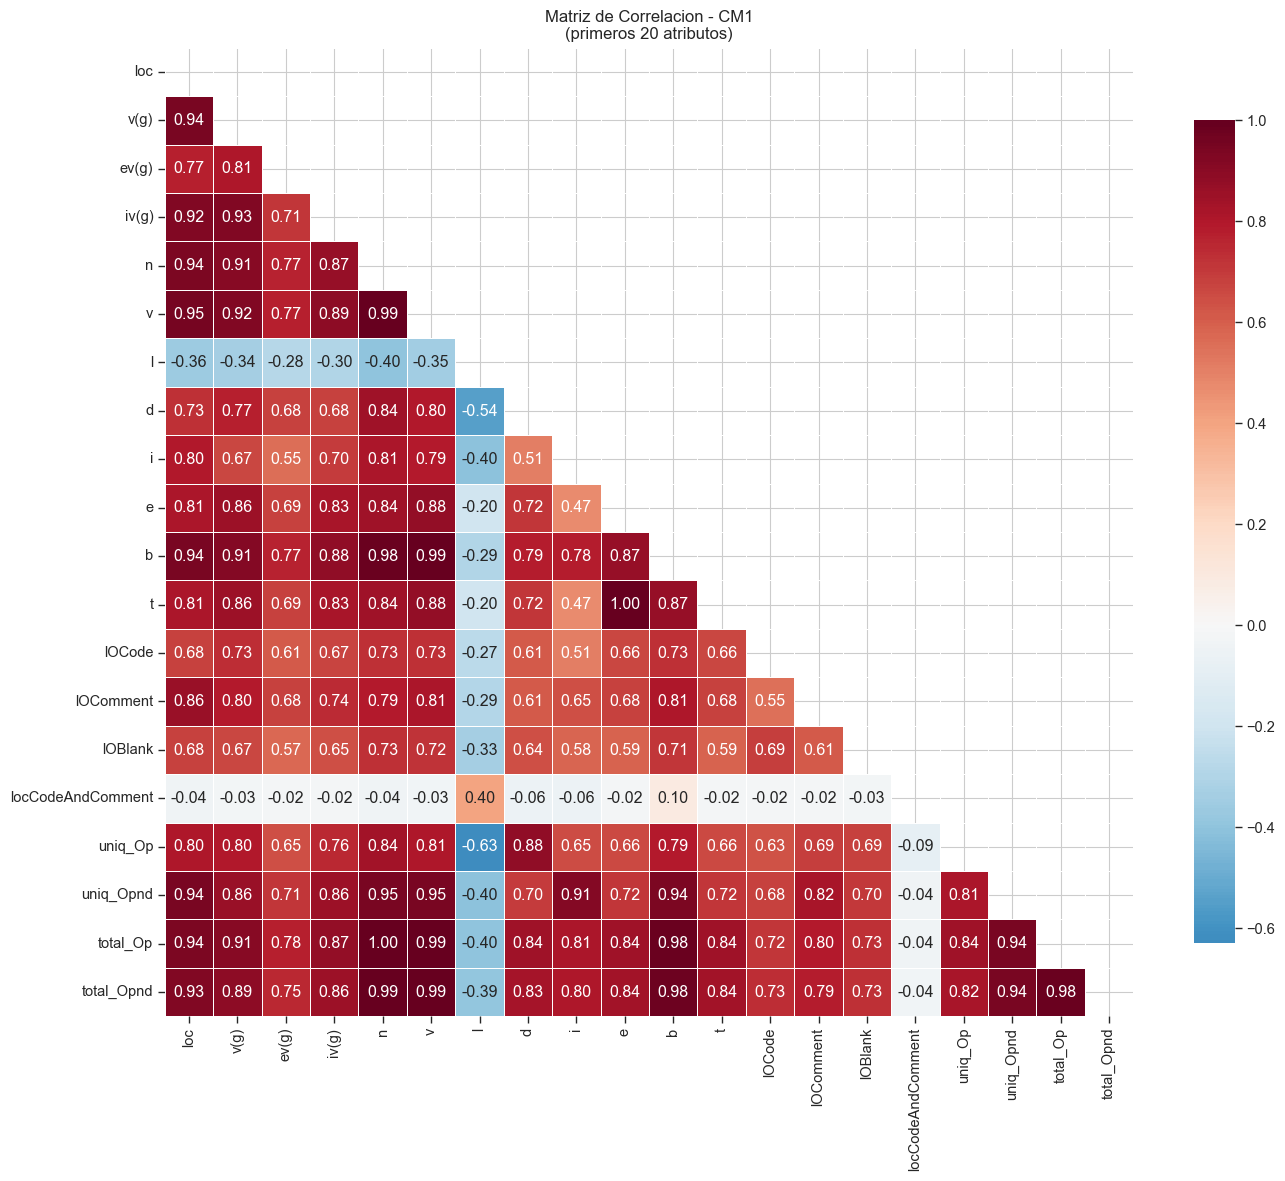

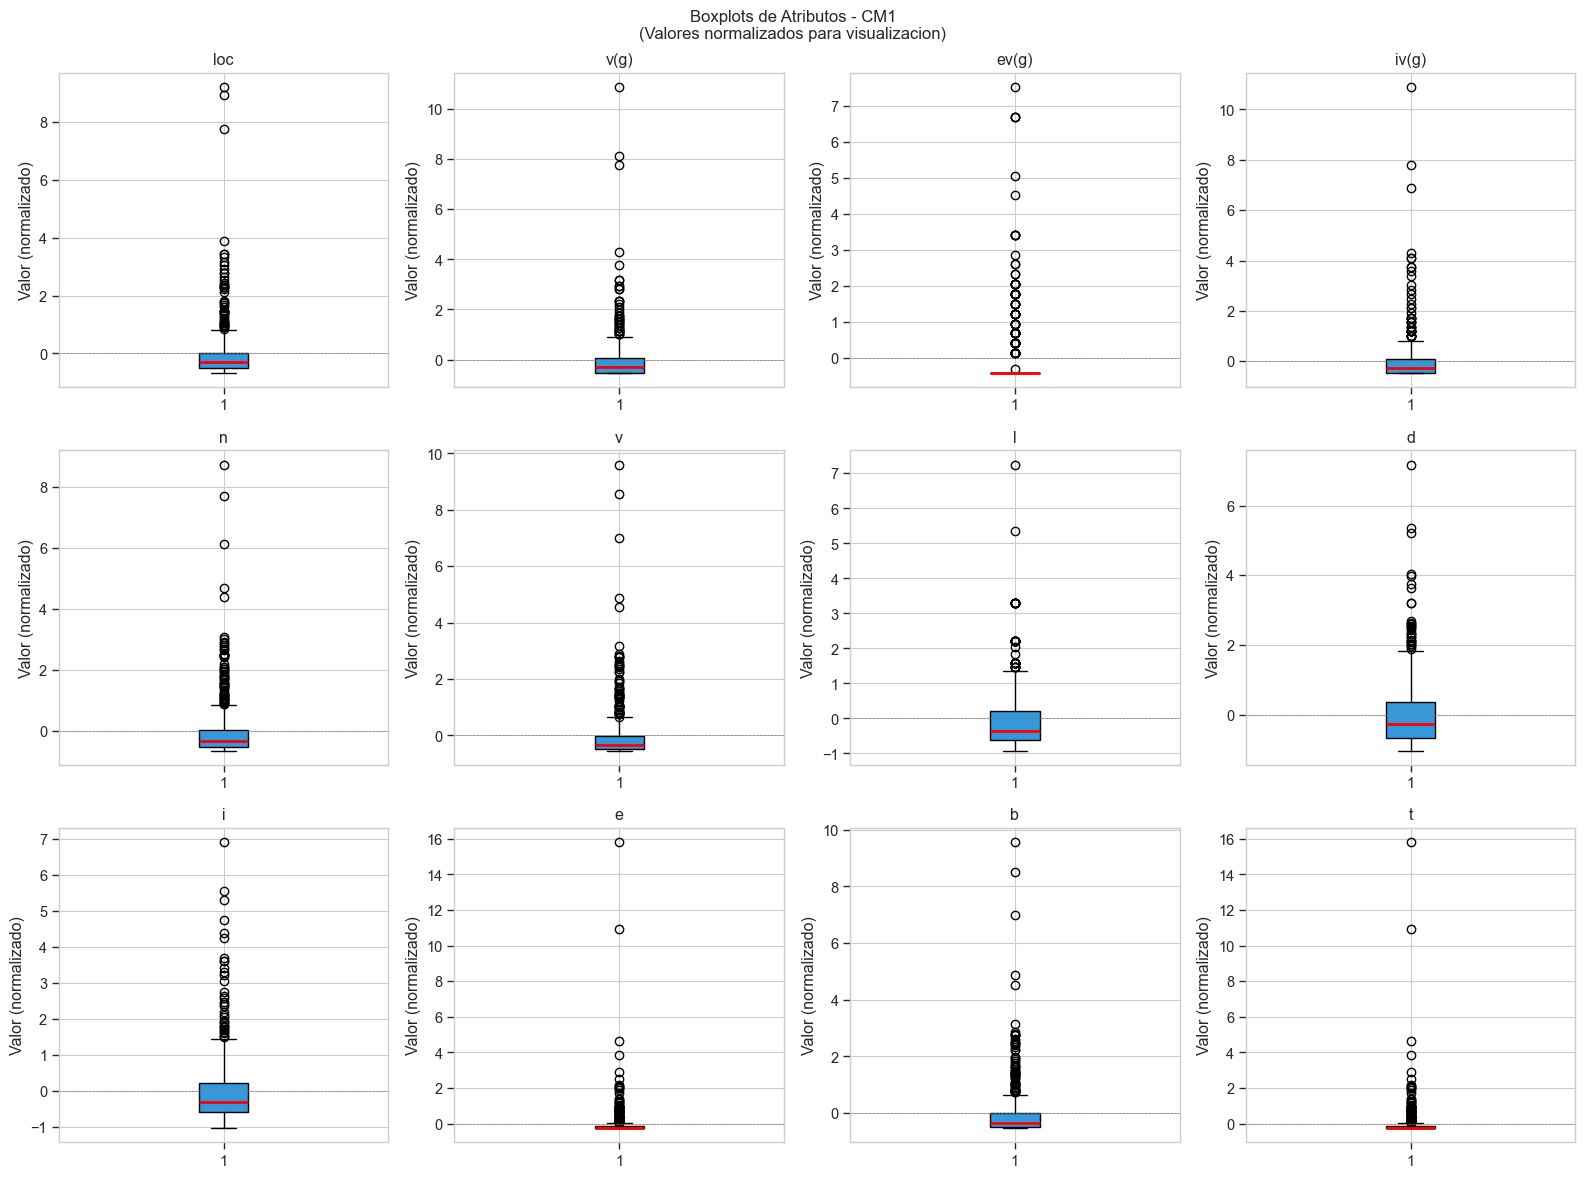


Resumen estadistico de CM1:
          loc    v(g)   ev(g)   iv(g)        n         v       l       d  \
count  498.00  498.00  498.00  498.00   498.00    498.00  498.00  498.00   
mean    29.64    5.38    2.49    3.53   143.96    900.18    0.15   15.83   
std     42.75    8.35    3.66    5.46   221.05   1690.81    0.16   15.33   
min      1.00    1.00    1.00    1.00     1.00      0.00    0.00    0.00   
25%      8.00    1.00    1.00    1.00    25.00    102.19    0.05    5.63   
50%     17.00    3.00    1.00    2.00    67.50    329.82    0.09   11.64   
75%     31.00    6.00    1.00    4.00   151.75    861.46    0.18   21.14   
max    423.00   96.00   30.00   63.00  2075.00  17124.28    1.30  125.77   

            i           e  ...          t  lOCode  lOComment  lOBlank  \
count  498.00      498.00  ...     498.00  498.00     498.00   498.00   
mean    38.46    34884.93  ...    1938.06    3.79      12.28    11.53   
std     37.00   134164.67  ...    7453.59    8.51      25.83    19.

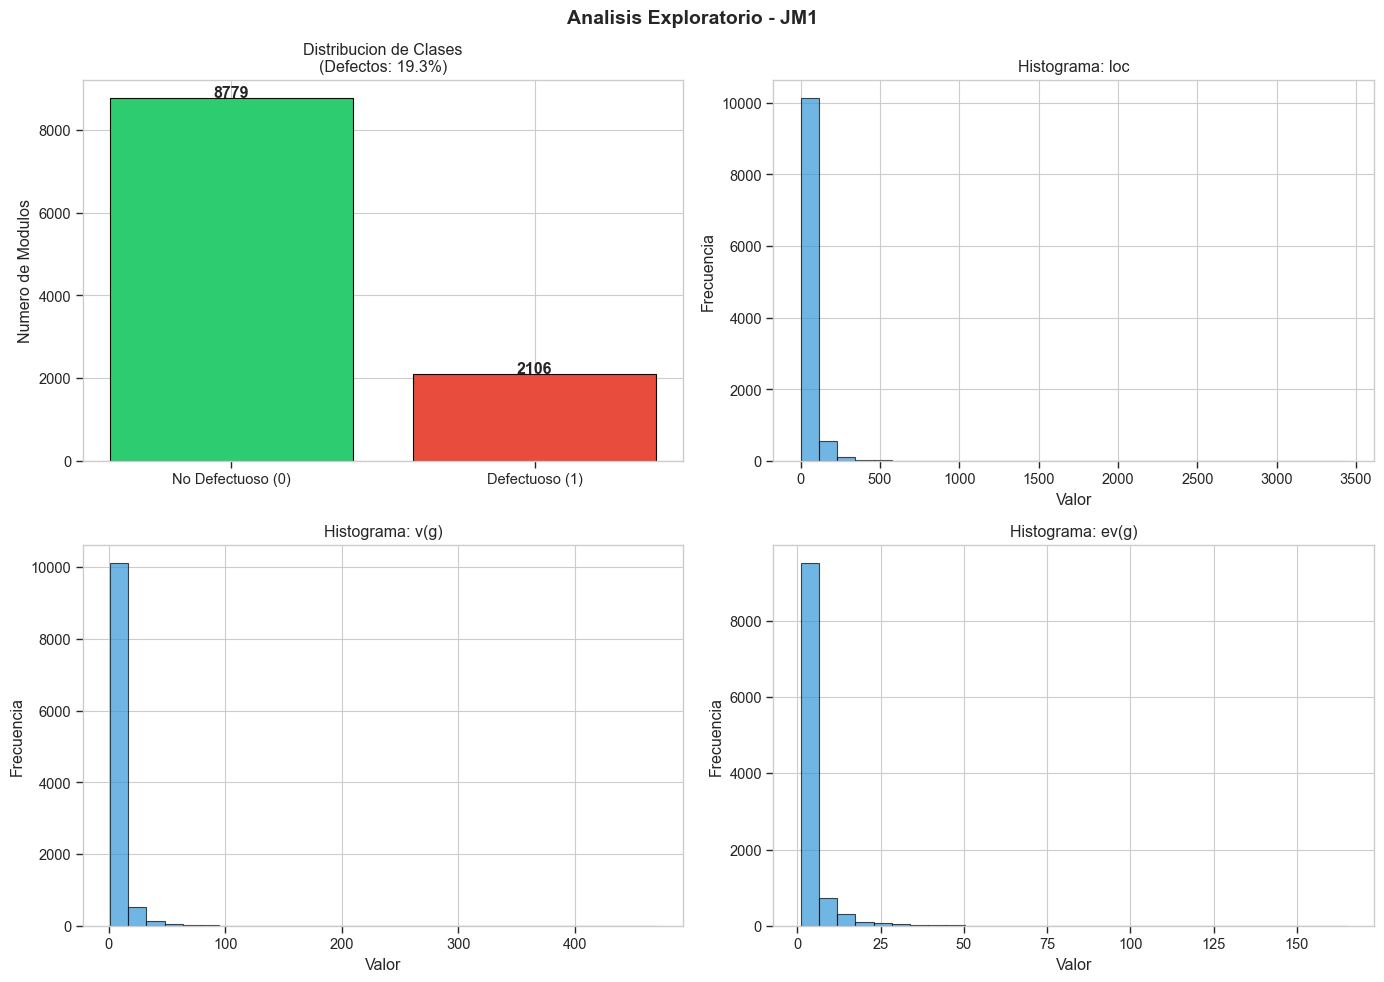

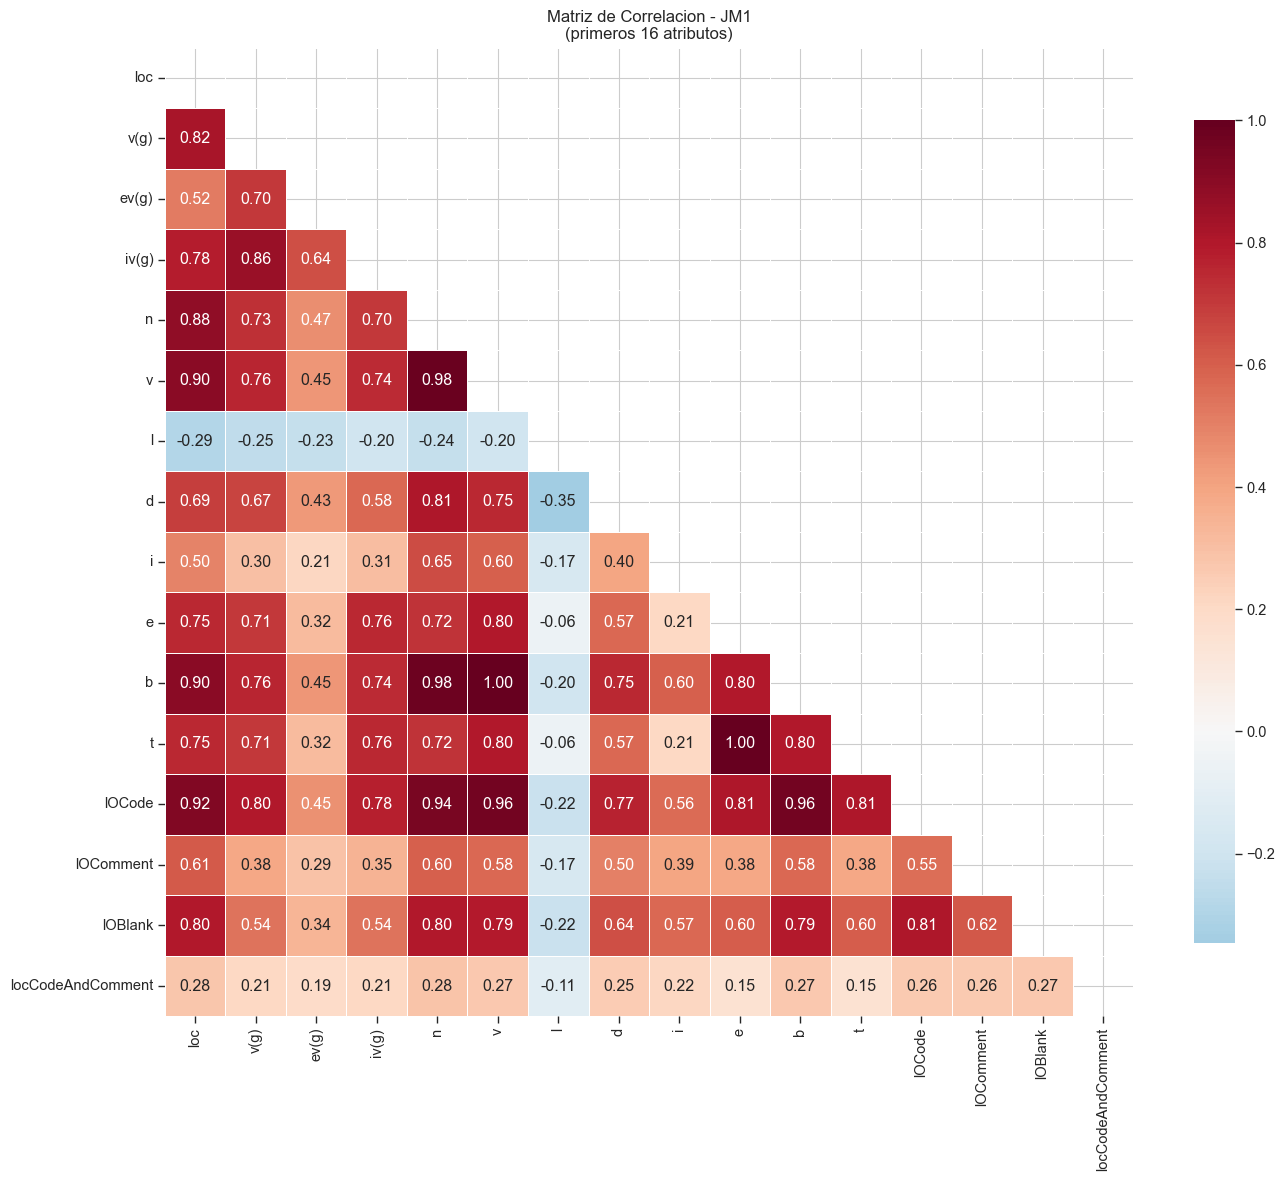

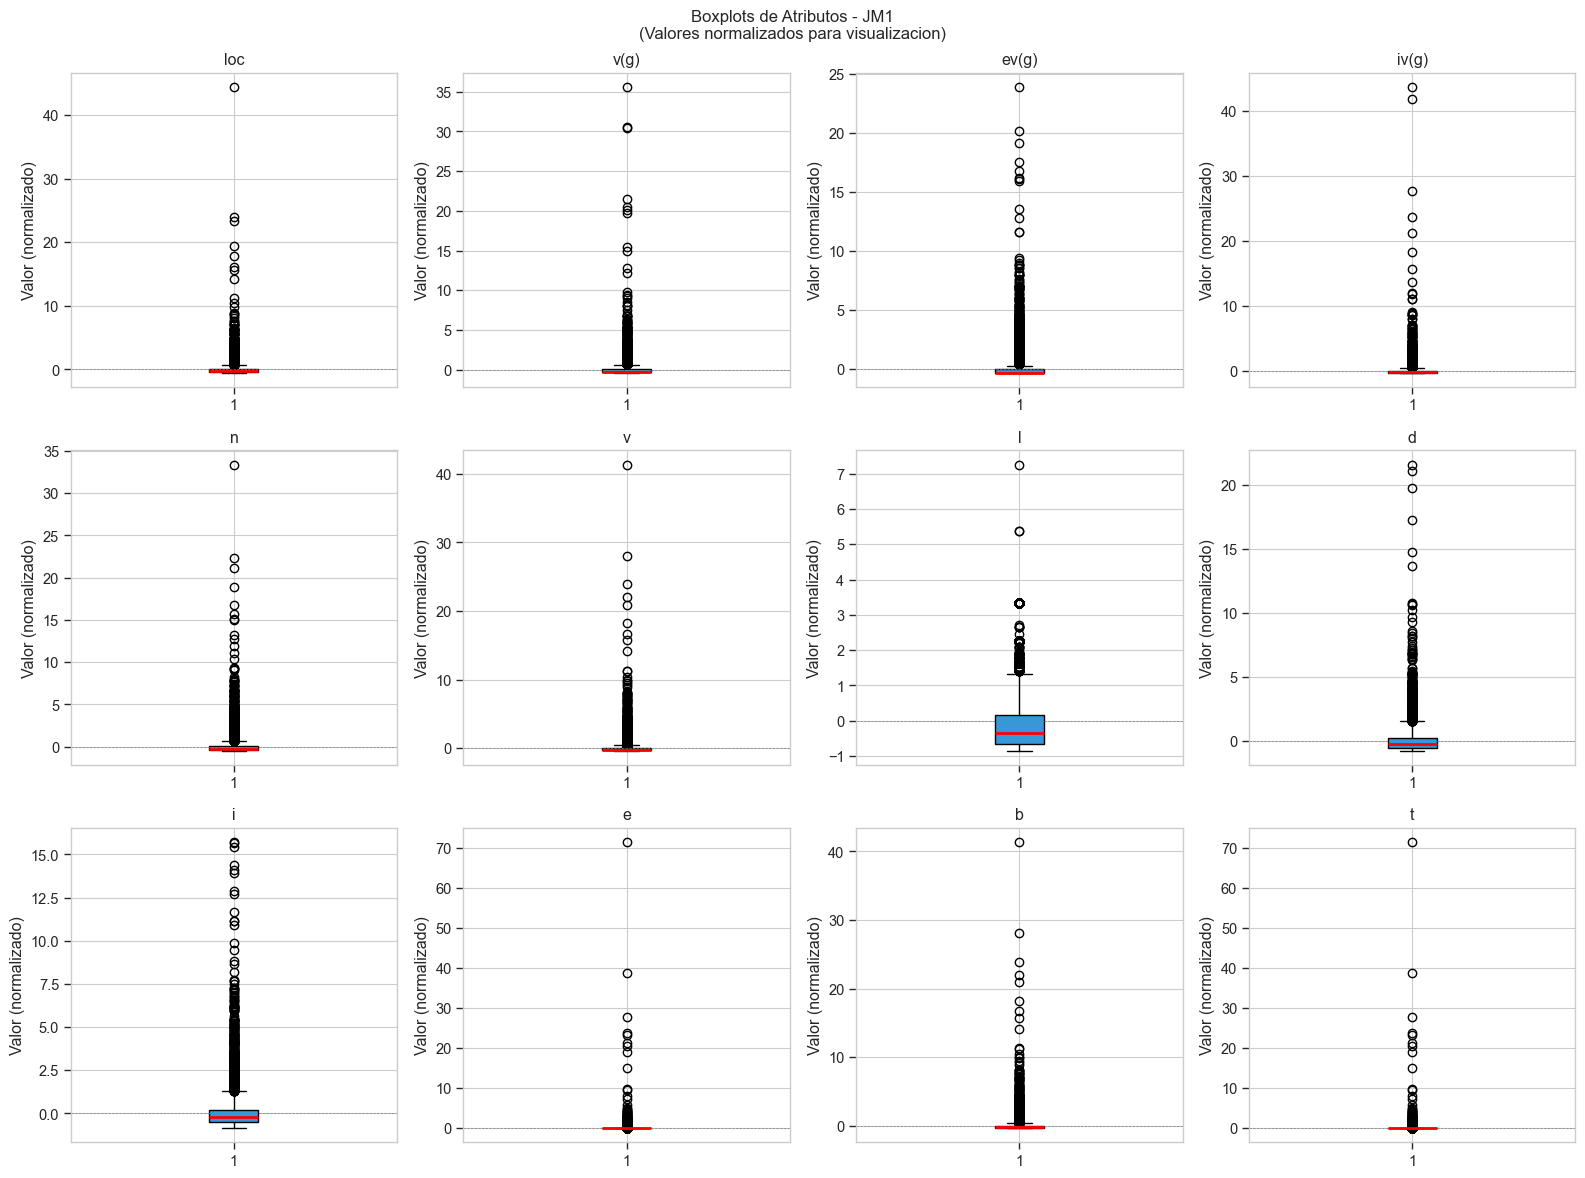


Resumen estadistico de JM1:
            loc      v(g)     ev(g)     iv(g)         n         v         l  \
count  10885.00  10885.00  10885.00  10885.00  10885.00  10885.00  10885.00   
mean      42.02      6.35      3.40      4.00    114.39    673.76      0.14   
std       76.59     13.02      6.77      9.12    249.50   1938.86      0.16   
min        1.00      1.00      1.00      1.00      0.00      0.00      0.00   
25%       11.00      2.00      1.00      1.00     14.00     48.43      0.03   
50%       23.00      3.00      1.00      2.00     49.00    217.13      0.08   
75%       46.00      7.00      3.00      4.00    119.00    621.48      0.16   
max     3442.00    470.00    165.00    402.00   8441.00  80843.08      1.30   

              d         i            e         b           t    lOCode  \
count  10885.00  10885.00     10885.00  10885.00    10885.00  10885.00   
mean      14.18     29.44     36836.37      0.22     2046.46     26.25   
std       18.71     34.42    434367.8

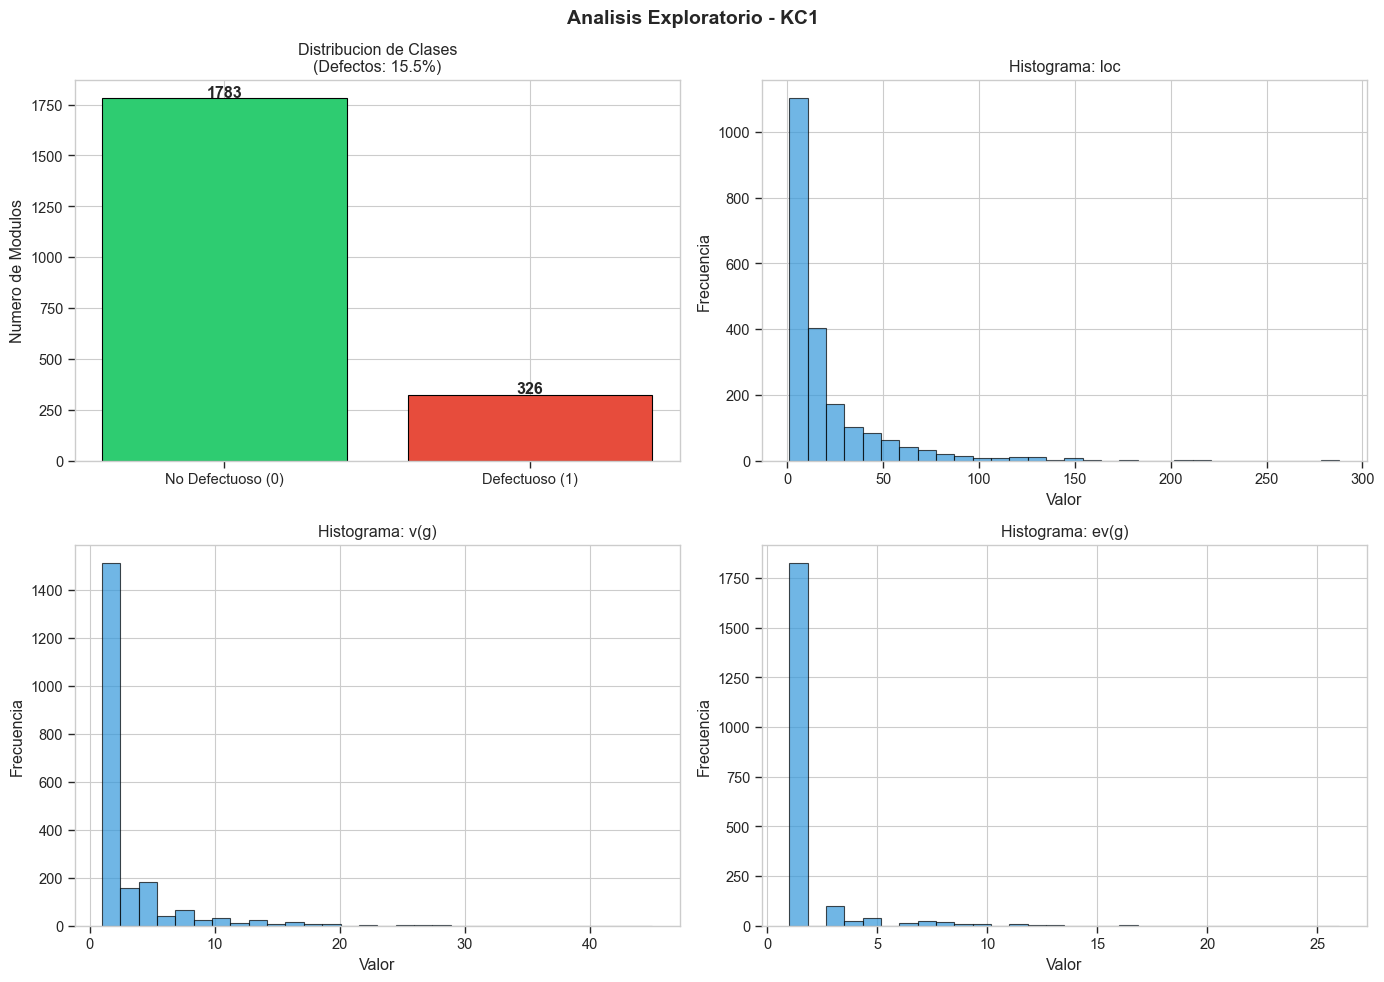

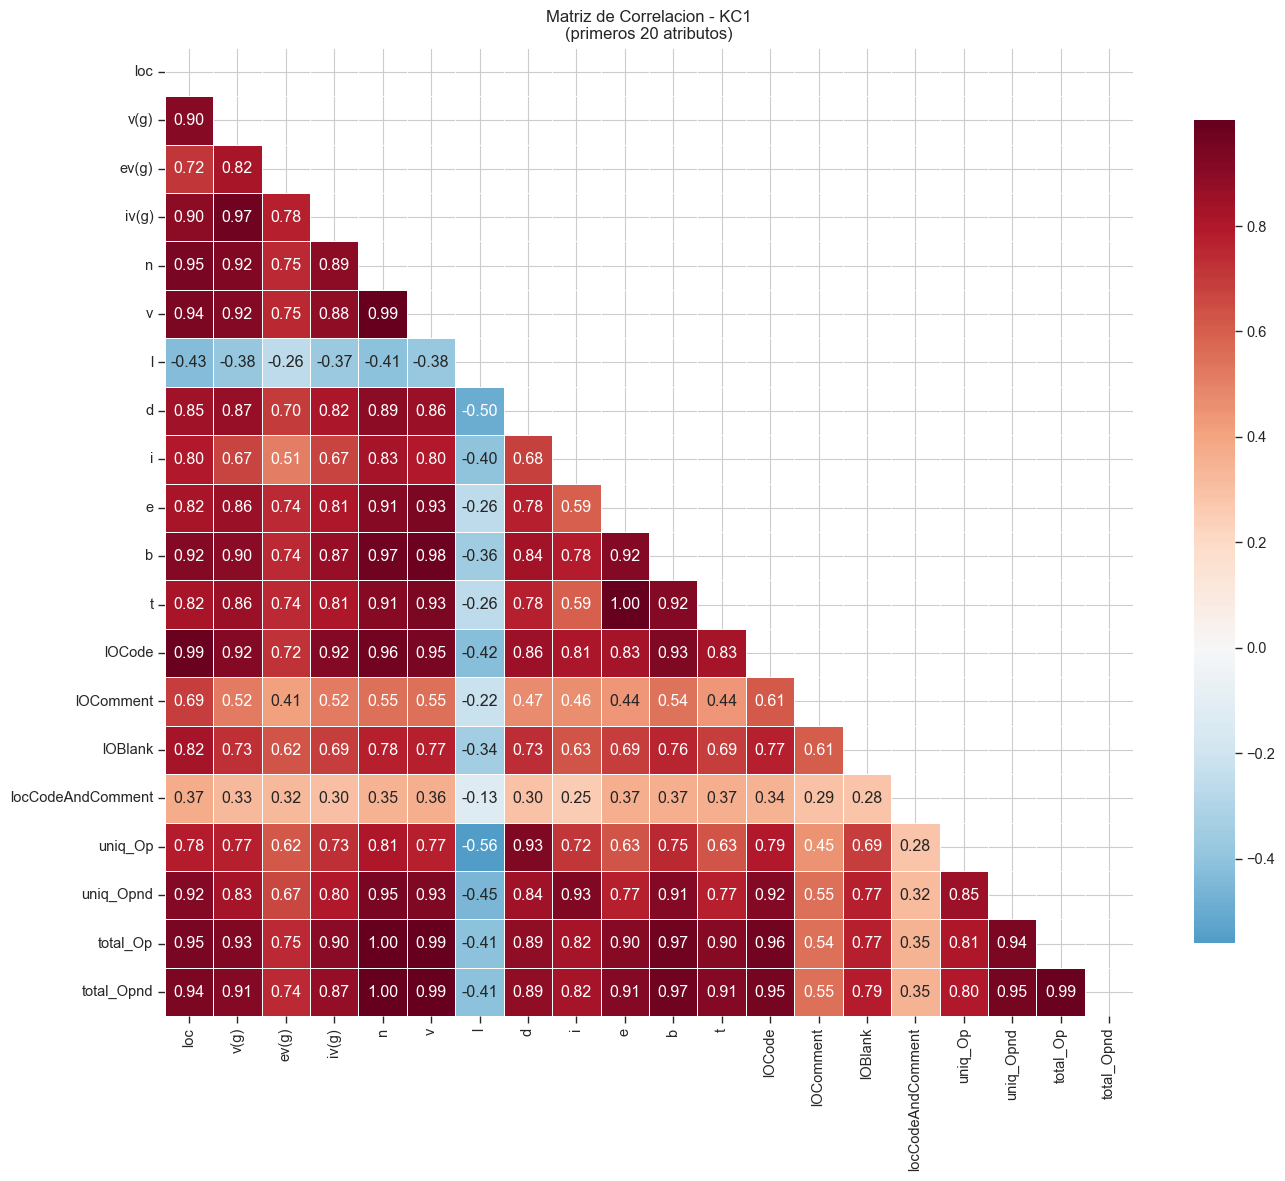

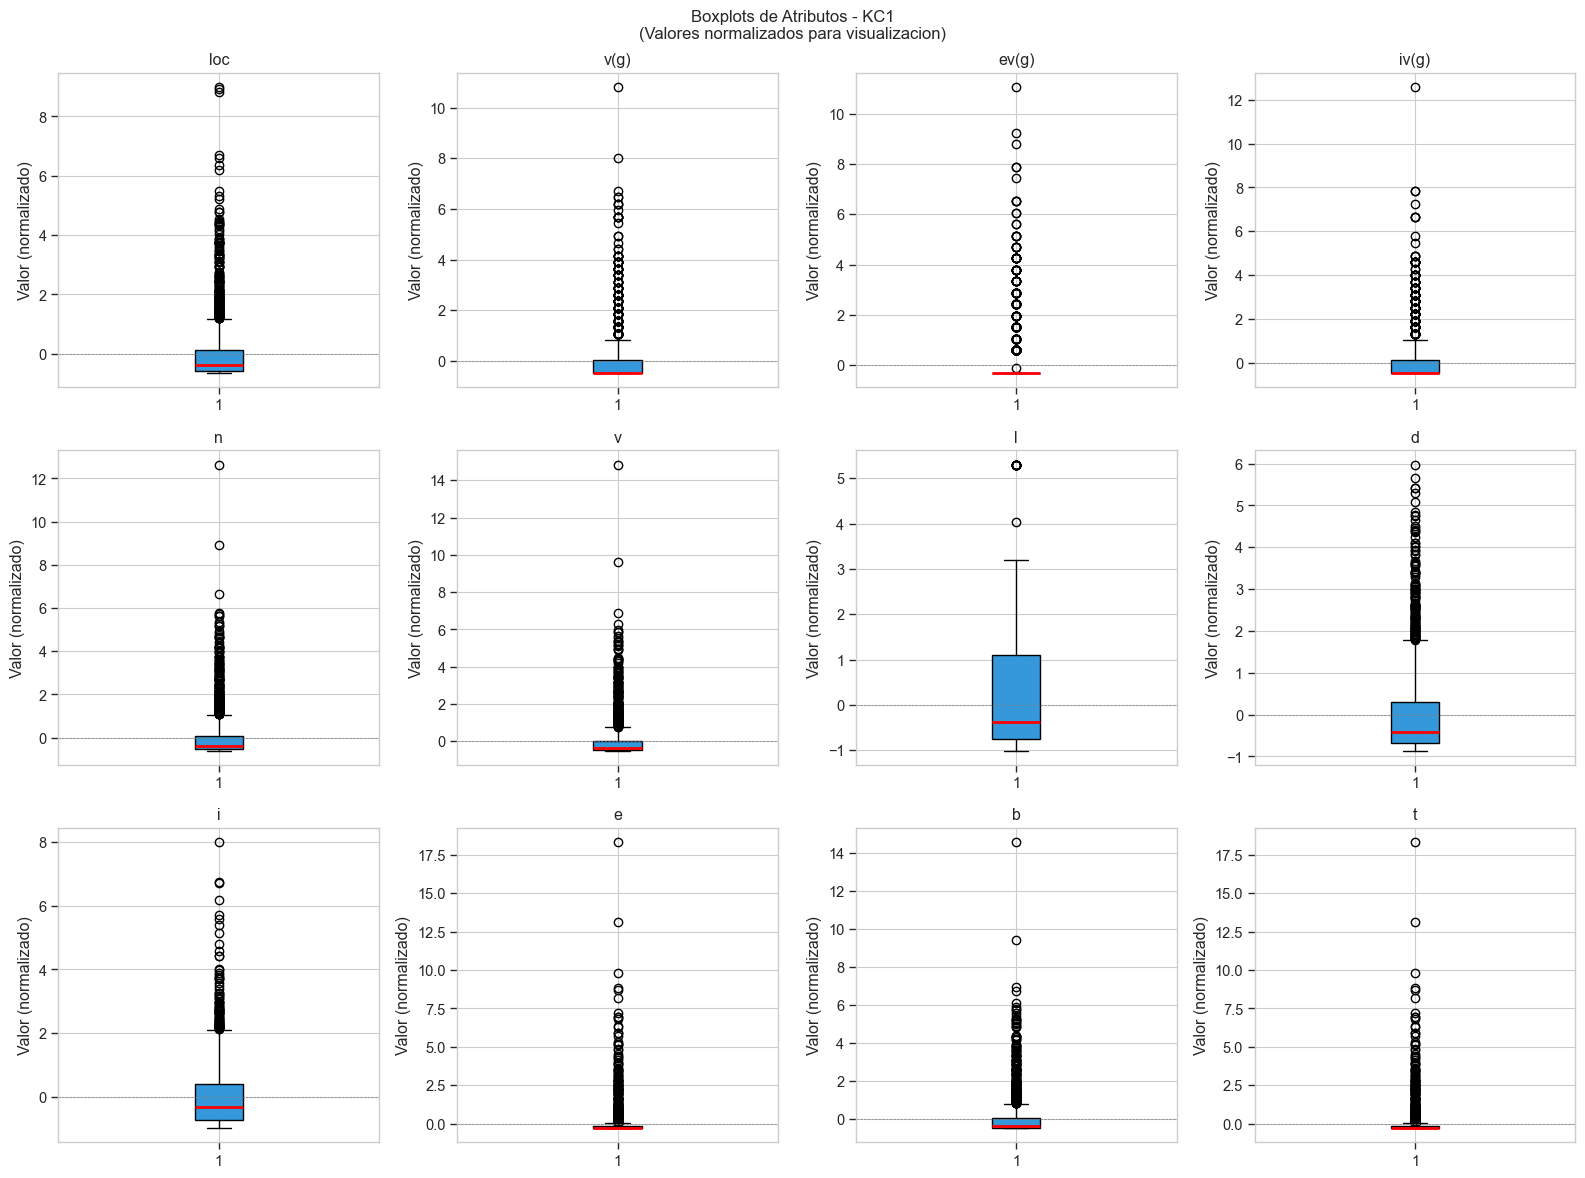


Resumen estadistico de KC1:
           loc     v(g)    ev(g)    iv(g)        n        v        l        d  \
count  2109.00  2109.00  2109.00  2109.00  2109.00  2109.00  2109.00  2109.00   
mean     20.37     2.84     1.67     2.55    49.83   258.70     0.32     6.77   
std      29.75     3.90     2.20     3.38    83.60   516.32     0.32     7.86   
min       1.00     1.00     1.00     1.00     0.00     0.00     0.00     0.00   
25%       3.00     1.00     1.00     1.00     4.00     8.00     0.08     1.50   
50%       9.00     1.00     1.00     1.00    16.00    57.06     0.20     3.50   
75%      24.00     3.00     1.00     3.00    58.00   265.93     0.67     9.20   
max     288.00    45.00    26.00    45.00  1106.00  7918.82     2.00    53.75   

             i          e  ...         t   lOCode  lOComment  lOBlank  \
count  2109.00    2109.00  ...   2109.00  2109.00    2109.00  2109.00   
mean     21.24    5242.39  ...    291.25    14.53       0.95     1.76   
std      21.50   17444

In [ ]:
informacion_datasets = {}

for nombre, ruta in DATASETS.items():
    X, y, info = cargar_dataset(ruta, nombre)
    if X is not None:
        informacion_datasets[nombre] = {'X': X, 'y': y, 'info': info}
        realizar_eda(X, y, info)

print("\nEDA completado para todos los datasets.")

#### 6) Evaluamos los algoritmos con validación cruzada
- X: Atributos
- y: Variable objetivo

In [68]:
def evaluar_algoritmo(X, y, algoritmo, nombre_algo, cv_folds=10):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    
    aucs = []
    precisiones = []
    recalls = []
    f1s = []
    
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        from sklearn.base import clone
        clf = clone(algoritmo)
        clf.fit(X_train, y_train)
        
        if hasattr(clf, "predict_proba"):
            y_pred_prob = clf.predict_proba(X_test)[:, 1]
        else:
            y_pred_prob = clf.decision_function(X_test)
        
        y_pred = clf.predict(X_test)
        
        try:
            auc = roc_auc_score(y_test, y_pred_prob)
        except:
            auc = 0.5
        
        precisiones.append(precision_score(y_test, y_pred, zero_division=0))
        recalls.append(recall_score(y_test, y_pred, zero_division=0))
        f1s.append(f1_score(y_test, y_pred, zero_division=0))
        aucs.append(auc)
    
    return {
        'AUC': np.mean(aucs),
        'AUC_std': np.std(aucs),
        'Precision': np.mean(precisiones),
        'Recall': np.mean(recalls),
        'F1': np.mean(f1s)
    }

#### 7) Definición de los algoritmos
- Punto 1: Configuracion base de algoritmos
- Punto 2: Configuraciones alternativas

In [69]:
# 1)
ALGORITMOS = {
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'J48 (Decision Tree)': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'MLP (Red Neuronal)': MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=RANDOM_STATE)
}

# Configuraciones alternativas (descomentar para experimentar)
# CONFIGURACIONES_ADICIONALES = {
#     'Random Forest (200 arboles)': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
#     'Random Forest (max_depth=15)': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=RANDOM_STATE),
#     'MLP (100-50-25)': MLPClassifier(hidden_layer_sizes=(100, 50, 25), max_iter=500, random_state=RANDOM_STATE),
#     'MLP (dropout simulado)': MLPClassifier(hidden_layer_sizes=(50, 25), alpha=0.01, max_iter=500, random_state=RANDOM_STATE),
#     'Decision Tree (sin limite)': DecisionTreeClassifier(random_state=RANDOM_STATE),
#     'Decision Tree (max_depth=5)': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
# }

print("Algoritmos definidos:")
for nombre in ALGORITMOS.keys():
    print(f"  - {nombre}")

Algoritmos definidos:
  - Naive Bayes
  - Random Forest
  - J48 (Decision Tree)
  - MLP (Red Neuronal)


#### 8) Ejecutamos los experimentos

In [70]:
resultados = []

for nombre, data in informacion_datasets.items():
    X, y, info = data['X'], data['y'], data['info']
    
    print(f"\nProcesando {nombre}:")
    print(f"  Instancias: {info['instancias']}, Atributos: {info['atributos']}")
    
    for nombre_algo, algoritmo in ALGORITMOS.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', algoritmo)
        ])
        
        print(f"  Evaluando: {nombre_algo}...")
        metricas = evaluar_algoritmo(X, y, pipeline, nombre_algo)
        
        resultados.append({
            'Dataset': nombre,
            'Algoritmo': nombre_algo,
            'Instancias': info['instancias'],
            'Defectos (%)': f"{info['pct_defectos']:.1f}%",
            'AUC': f"{metricas['AUC']:.3f}",
            'AUC_std': f"{metricas['AUC_std']:.3f}",
            'Precision': f"{metricas['Precision']:.3f}",
            'Recall': f"{metricas['Recall']:.3f}",
            'F1-Score': f"{metricas['F1']:.3f}"
        })

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(['Dataset', 'AUC'], ascending=[True, False])

print("\nExperimentos completados.")


EJECUTANDO EXPERIMENTOS DE CLASIFICACION

Procesando CM1:
  Instancias: 498, Atributos: 21
  Evaluando: Naive Bayes...
  Evaluando: Random Forest...
  Evaluando: J48 (Decision Tree)...
  Evaluando: MLP (Red Neuronal)...

Procesando JM1:
  Instancias: 10885, Atributos: 16
  Evaluando: Naive Bayes...
  Evaluando: Random Forest...
  Evaluando: J48 (Decision Tree)...
  Evaluando: MLP (Red Neuronal)...

Procesando KC1:
  Instancias: 2109, Atributos: 21
  Evaluando: Naive Bayes...
  Evaluando: Random Forest...
  Evaluando: J48 (Decision Tree)...
  Evaluando: MLP (Red Neuronal)...

Experimentos completados.


#### 9) Función para graficar resultados comparativos
- Genera grafico de barras comparando AUC entre algoritmos y datasets.

In [73]:
def graficar_resultados_comparativos(df):
    df_plot = df.copy()
    df_plot['AUC_float'] = df_plot['AUC'].astype(float)
    df_plot['AUC_std_float'] = df_plot['AUC_std'].astype(float)
    
    datasets_unicos = df_plot['Dataset'].unique()
    algoritmos_unicos = df_plot['Algoritmo'].unique()
    
    x = np.arange(len(datasets_unicos))
    width = 0.8 / len(algoritmos_unicos)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, (algo, color) in enumerate(zip(algoritmos_unicos, colores)):
        auc_values = []
        auc_stds = []
        for ds in datasets_unicos:
            row = df_plot[(df_plot['Dataset'] == ds) & (df_plot['Algoritmo'] == algo)]
            if len(row) > 0:
                auc_values.append(row['AUC_float'].values[0])
                auc_stds.append(row['AUC_std_float'].values[0])
            else:
                auc_values.append(0)
                auc_stds.append(0)
        
        offset = (i - len(algoritmos_unicos)/2) * width + width/2
        bars = ax.bar(x + offset, auc_values, width, label=algo, color=color, 
                      yerr=auc_stds, capsize=3, error_kw={'elinewidth': 1, 'capthick': 1})
    
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel('AUC (Area Under ROC Curve)', fontsize=12)
    ax.set_title('Comparacion de AUC por Dataset y Algoritmo', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets_unicos)
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Clasificador aleatorio (0.5)')
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../resultados_comparativos.png', dpi=150)
    plt.show()


#### 10) Generamos gráfico comparativo

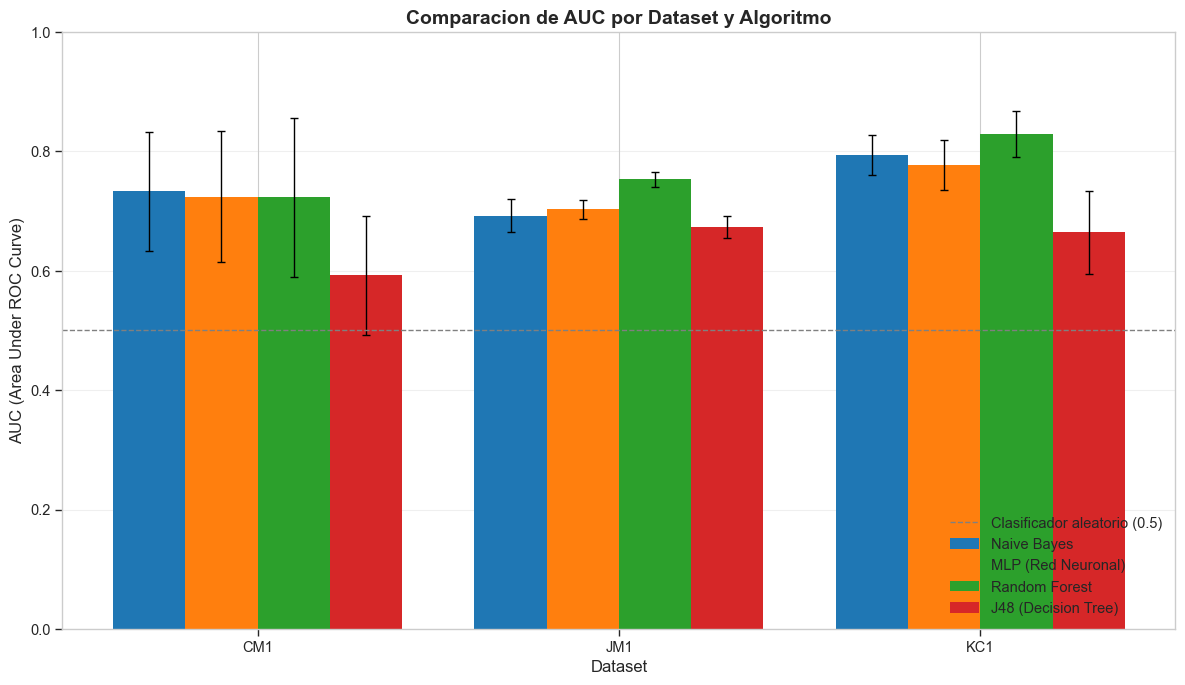

In [74]:
graficar_resultados_comparativos(df_resultados)

#### 11) Generar tabla LaTeX (guardar en archivo)

In [84]:
def generar_tabla_latex(df, output_path='../tabla_resultados.tex'):
    """
    Genera una tabla en formato LaTeX y la guarda en un archivo.
    """
    lineas = []
    lineas.append("\\begin{table}[h]")
    lineas.append("\\centering")
    lineas.append("\\caption{Resultados de clasificacion para datasets NASA-MDP}")
    lineas.append("\\begin{tabular}{|l|l|c|c|c|c|}")
    lineas.append("\\hline")
    lineas.append("\\textbf{Dataset} & \\textbf{Algoritmo} & \\textbf{AUC} & \\textbf{Precisión} & \\textbf{Recall} & \\textbf{F1-Score} \\\\")
    lineas.append("\\hline")
    
    for _, row in df.iterrows():
        linea = f"{row['Dataset']} & {row['Algoritmo']} & {row['AUC']} & {row['Precision']} & {row['Recall']} & {row['F1-Score']} \\\\"
        lineas.append(linea)
        lineas.append("\\hline")
    
    lineas.append("\\end{tabular}")
    lineas.append("\\label{tab:resultados}")
    lineas.append("\\end{table}")
    
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lineas))
    
    print(f"Tabla LaTeX guardada en: {output_path}")

generar_tabla_latex(df_resultados)

Tabla LaTeX guardada en: ../tabla_resultados.tex


#### 12) Resultados en consola y resumen estadístico

In [83]:
print("RESULTADOS FINALES")
print(df_resultados[['Dataset', 'Algoritmo', 'AUC', 'Precision', 'Recall', 'F1-Score']].to_string(index=False))
print("=" * 70)


# RESUMEN ESTADISTICO DE RESULTADOS
print("\n" + "=" * 70)
print("RESUMEN ESTADISTICO DE RESULTADOS")


for ds in df_resultados['Dataset'].unique():
    df_ds = df_resultados[df_resultados['Dataset'] == ds]
    mejor_fila = df_ds.iloc[0]
    print(f"\n{ds}:")
    print(f"  Mejor algoritmo: {mejor_fila['Algoritmo']}")
    print(f"  Mejor AUC: {mejor_fila['AUC']}")


RESULTADOS FINALES
Dataset           Algoritmo   AUC Precision Recall F1-Score
    CM1         Naive Bayes 0.733     0.262  0.345    0.281
    CM1  MLP (Red Neuronal) 0.724     0.233  0.140    0.173
    CM1       Random Forest 0.723     0.100  0.040    0.057
    CM1 J48 (Decision Tree) 0.592     0.162  0.145    0.152
    JM1       Random Forest 0.753     0.564  0.236    0.332
    JM1  MLP (Red Neuronal) 0.703     0.504  0.208    0.293
    JM1         Naive Bayes 0.692     0.486  0.194    0.277
    JM1 J48 (Decision Tree) 0.673     0.453  0.206    0.282
    KC1       Random Forest 0.829     0.610  0.325    0.417
    KC1         Naive Bayes 0.794     0.427  0.371    0.395
    KC1  MLP (Red Neuronal) 0.777     0.557  0.353    0.428
    KC1 J48 (Decision Tree) 0.664     0.427  0.273    0.326

RESUMEN ESTADISTICO DE RESULTADOS

CM1:
  Mejor algoritmo: Naive Bayes
  Mejor AUC: 0.733

JM1:
  Mejor algoritmo: Random Forest
  Mejor AUC: 0.753

KC1:
  Mejor algoritmo: Random Forest
  Mejor AUC: 